2.1理论计算题

1、-8

2、A是2*3，B是3*2，结果形状是2*2。
第一行第一列：(−1)×2+0×0+2×2=−2+0+4=2
第一行第二列：(−1)×1+0×3+2×(−1)=−1+0−2=−3
第二行第一列：1×2+3×0+1×2=2+0+2=4
第二行第二列：1×1+3×3+1×(−1)=1+9−1=9

3、√14

2.2编程题

In [73]:
import numpy as np

In [74]:
#1、创建形状3*4的随机矩阵X，元素服从标准正态分布
X = np.random.randn(3,4)

In [75]:
#2、创建形状4*2的全1矩阵Y
Y = np.ones((4,2))

In [76]:
#3、计算矩阵乘法 Z= X @ Y
Z = X @ Y

In [77]:
# 4. 输出 Z 的第一行和第二列交叉处的元素，以及 Z 的第 2 行所有元素
element = Z[0, 1]   
second_row = Z[1, :]  

print("Z = \n", Z)
print("Z 的第一行第二列元素:", element)
print("Z 的第 2 行所有元素:", second_row)

Z = 
 [[ 0.43645632  0.43645632]
 [-2.42507037 -2.42507037]
 [ 0.82950547  0.82950547]]
Z 的第一行第二列元素: 0.4364563184606727
Z 的第 2 行所有元素: [-2.42507037 -2.42507037]


In [78]:
# 5. 计算 Z 的 Frobenius 范数
fro_norm = np.linalg.norm(Z, 'fro')
print("Z 的 Frobenius 范数:", fro_norm)

Z 的 Frobenius 范数: 3.6768300922038613


3.1理论计算题：4.72%

3.2编程题：用 Python 模拟中心极限定理

In [79]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

#存储每次的样本均值
sample_means= []

In [80]:
# 1. 生成 n 个 U(0,1) 随机变量，重复 m 次，每次计算均值

n = 10000
m = 1000

for i in range(m):
    sample = np.random.uniform(0,1,n)
    mean_val = np.mean(sample)
    sample_means.append(mean_val)

# 转换成 numpy 数组
sample_means = np.array(sample_means)

In [81]:
# 3. 计算这些均值的实际方差
actual_variance = np.var(sample_means, ddof=0)   # 总体方差（因为 m 次重复可视为整体）
print(f"均值的实际方差: {actual_variance:.8f}")

# 理论方差：U(0,1) 的方差 = 1/12，样本均值的理论方差 = (1/12)/n
theoretical_variance = (1/12) / 10000
print(f"理论方差: {theoretical_variance:.8f}")

均值的实际方差: 0.00000866
理论方差: 0.00000833


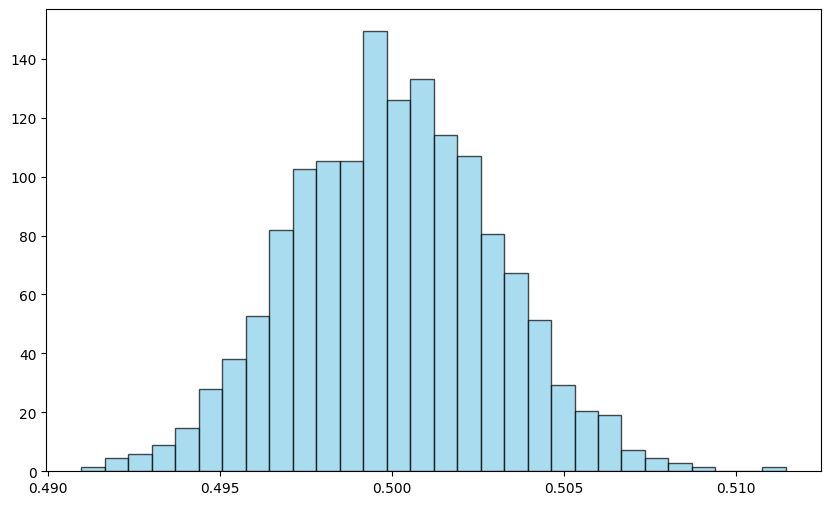

In [82]:
# 2. 绘制直方图并叠加理论正态分布曲线
plt.figure(figsize=(10, 6))

# 直方图（density=True 归一化，便于与概率密度曲线比较）
count, bins, ignored = plt.hist(sample_means, bins=30, density=True, 
                                alpha=0.7, color='skyblue', edgecolor='black')

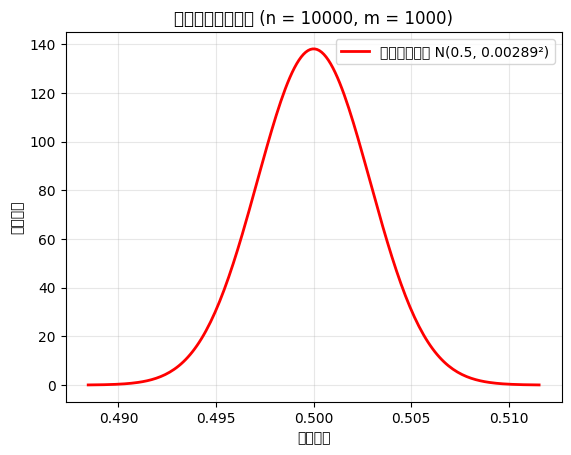

In [83]:
# 理论正态分布：均值 0.5，方差 theoretical_variance
mu_theory = 0.5
sigma_theory = np.sqrt(theoretical_variance)
x = np.linspace(mu_theory - 4*sigma_theory, mu_theory + 4*sigma_theory, 200)
pdf = norm.pdf(x, mu_theory, sigma_theory)
plt.plot(x, pdf, 'r-', linewidth=2, label=f'理论正态分布 N(0.5, {sigma_theory:.5f}²)')

plt.xlabel('样本均值')
plt.ylabel('概率密度')
plt.title(f'中心极限定理验证 (n = {n}, m = {m})')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

4.1理论计算题

1、8w1+4w2-12;
4w1+2w2-6

2、-4；-2

4.2编程题

In [84]:
#1、定义向前计算
def forward(x, w1, w2):
    """
    前向计算
    a = x * w1
    b = a + w2
    L = b^2
    """
    a = x * w1
    b = a + w2
    L = b ** 2
    return L, a, b

In [85]:
#2、给定数值计算向前结果
x = 2.0
w1 = 1.5
w2 = 0.5

L, a, b = forward(x, w1, w2)

print(f"a = {a}")   # a = 3.0
print(f"b = {b}")   # b = 3.5
print(f"L = {L}")   # L = 12.25

a = 3.0
b = 3.5
L = 12.25


3、手动结果14；7

In [89]:
#用pytorch自动微分验证

import torch

# 定义需要梯度的变量
w1_t = torch.tensor(1.5, requires_grad=True)
w2_t = torch.tensor(0.5, requires_grad=True)
x_t = torch.tensor(2.0)

# 前向计算
a_t = x_t * w1_t
b_t = a_t + w2_t
L_t = b_t ** 2

# 反向传播
L_t.backward()

print(f"PyTorch 计算的 dL/dw1 = {w1_t.grad.item()}")
print(f"PyTorch 计算的 dL/dw2 = {w2_t.grad.item()}")

# 验证一致性
assert w1_t.grad.item() == 14.0
assert w2_t.grad.item() == 7.0
print(" 手动计算与自动微分结果完全一致")

PyTorch 计算的 dL/dw1 = 14.0
PyTorch 计算的 dL/dw2 = 7.0
 手动计算与自动微分结果完全一致


5.1理论计算题